In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [19]:
housing_df = pd.read_csv('/content/california_housing.csv')

# Assuming the last column is the target variable
X = housing_df.iloc[:, :-1].values
y = housing_df.iloc[:, -1].values

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (20640, 7)
Target Shape : (20640,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(7,)),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [32]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5155.7139 - mae: 57.0547 - val_loss: 579.9192 - val_mae: 16.7261
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 368.2330 - mae: 13.0151 - val_loss: 225.5662 - val_mae: 10.2619
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 146.3727 - mae: 7.8276 - val_loss: 90.5508 - val_mae: 5.9581
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 59.6421 - mae: 4.5995 - val_loss: 36.2708 - val_mae: 3.3795
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23.5230 - mae: 2.7021 - val_loss: 17.6677 - val_mae: 2.2672
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.2894 - mae: 1.7461 - val_loss: 10.3657 - val_mae: 1.4501
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.5181 - mae: 1.2429 - val_loss: 6.4873 - val_mae: 1.0939
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.7906 - mae: 0.9825 - val_loss: 4.8289 - val_mae: 0.9251
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━

In [33]:
y_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [34]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nModel Evaluation")
print("-------------------------")
print("MSE  :", mse)
print("MAE  :", mae)
print("RMSE :", rmse)


Model Evaluation
-------------------------
MSE  : 0.7786935230445955
MAE  : 0.4110321525455446
RMSE : 0.8824361297253165


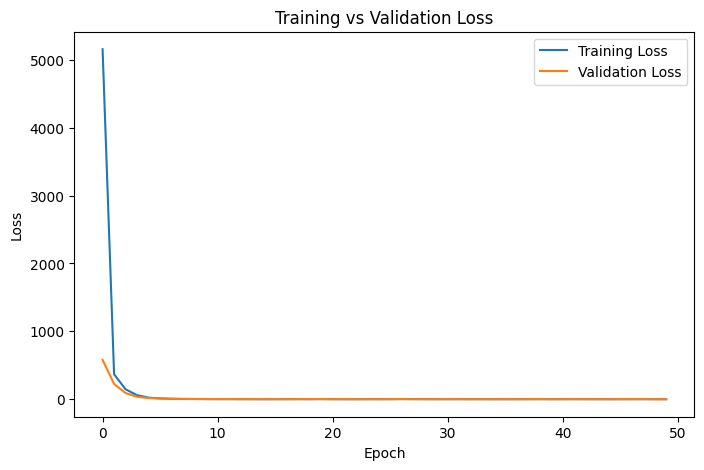

In [35]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()